## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # normalization / logarithm

remove_outer = True
groups_to_remove = [0, 14]

elements_to_keep = [
                     'Al',
                     'S',
                     'Cr',
                     'Mn',
                     'Co',
                     'Cu',
                     'Zn',
                     'Pb'
                    ]

columns_to_keep_inks = {
                        'Books': [el + '_inks' for el in elements_to_keep],
                        'Documents_XVIII_century' : [el + '_inks' for el in elements_to_keep]
                        }

columns_to_keep_inds = { 
                        'Books' : [el + '_inds' for el in elements_to_keep],
                        'Documents_XVIII_century' : [el + '_inds' for el in elements_to_keep]
                        }

data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/treningowe_DANE_TOTAL.csv'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/'}

## Loading the data

In [4]:
df = pd.read_csv(data_path[object_name])

In [5]:
if object_name == 'Books':
    
    df = pd.ExcelFile(data_path[object_name])
    # 1425: we are using only real samples, discarding simulated
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    
elif object_name == 'Documents_XVIII_century':
    
    df = pd.read_csv(data_path[object_name])
    inks_df = df[[col for col in df.columns if col.endswith('_a')]]
    inks_df.columns = [col.split('_')[0] for col in inks_df.columns]
    inds_df = df[[col for col in df.columns if col.endswith('_i')]]
    inds_df.columns = [col.split('_')[0] for col in inds_df.columns]

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

### Keeping track of the records from the same sample

In [7]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's remove 'outer' samples:

In [8]:
if remove_outer:
    inDKs_df = inDKs_df[inDKs_df['index_inds'].apply(lambda x: x%15 not in groups_to_remove)]

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [9]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

3. Let's remove rows with missing values.

In [10]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.0

In [11]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [12]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Creating features and labels matrices

In [13]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [14]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [15]:
if preprocessing_method == 'normalization':

    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

/tmp/ipykernel_23695/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


In [16]:
#plt.hist(X_val[:,2], bins=100)

### Converting to tensors

In [17]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [18]:
X_train = torch.Tensor(X_train).to(device)
y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [19]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [20]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [21]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [22]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [23]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [24]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=256, bias=True)
    (10): Dropout(p=0.02, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): Dropout(p=0.02, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=64, bias=True)
    (16): Dropout(p=0.02, inplace=False)
    (17): ReLU()
    (18): Linear(in_features=64, out_features=32, bias=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): ReLU()
    (21): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [25]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [26]:
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [27]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 5.531944813935653 test 4.1686313908929264
EPOCH 2:
LOSS train 2.8820365356362383 test 1.5354129856244152
EPOCH 3:
LOSS train 1.6300983739935833 test 1.3395773541822484
EPOCH 4:
LOSS train 1.5199106206064639 test 1.3368587306694346
EPOCH 5:
LOSS train 1.457867980003357 test 1.2902320877608813
EPOCH 6:
LOSS train 1.4501856772795967 test 1.3170908491997015
EPOCH 7:
LOSS train 1.4351666958435723 test 1.2943853839760058
EPOCH 8:
LOSS train 1.4223682569420857 test 1.4454882037550898
EPOCH 9:
LOSS train 1.4384236698565276 test 1.3250746362417412
EPOCH 10:
LOSS train 1.4018487774807473 test 1.2455727479430432
EPOCH 11:
LOSS train 1.4418167186819988 test 1.2457994270195656
EPOCH 12:
LOSS train 1.422618285469387 test 1.256642486225607
EPOCH 13:
LOSS train 1.3878126092579053 test 1.238852395705667
EPOCH 14:
LOSS train 1.3938110704007356 test 1.2800664042192478
EPOCH 15:
LOSS train 1.377859115600586 test 1.365407621909704
EPOCH 16:
LOSS train 1.395479036414105 test 1.2506398465

KeyboardInterrupt: 

In [ ]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [ ]:
%matplotlib notebook

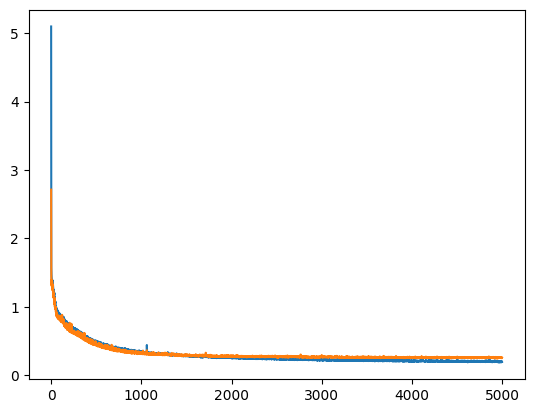

In [31]:
plt.plot(train_losses)
plt.plot(val_losses)

## Loading pretrained model

In [32]:
path = models_path[object_name] + 'model_regression_Documents_XVIII_century_sample_split_logarithm_outer_removed_Al_S_Cr_Mn_Co_Cu_Zn_Pb_2024_12_07_23_35_27'

model = InksNet().to(device)
model.load_state_dict(torch.load(path))

/tmp/ipykernel_4757/1686141604.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


<All keys matched successfully>

## Prediction on test set

In [29]:
model.eval()
loss_fn = CustomLoss()

running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [30]:
lab

tensor([[ -2.0875,  -5.6905,  -8.1068,  ...,  -6.0084,  -6.3862,  -4.0627],
        [ -1.4597,  -6.6334,  -7.7688,  ...,  -4.9681,  -7.7440,  -1.6999],
        [ -2.4878,  -5.9611,  -9.4677,  ...,  -6.1412,  -9.2673,  -5.0380],
        ...,
        [  0.6359,  -5.6427,  -1.0220,  ...,  -4.0298,  -4.5839,  -1.4620],
        [ -1.1358,  -7.5289,  -5.2262,  ...,  -6.1890,  -7.1514,  -3.2901],
        [ -5.4973,  -6.2577, -10.3906,  ...,  -0.9081,  -2.3840,  -4.7991]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [42]:
out

tensor([[-2.3687, -5.9968, -8.5668,  ..., -6.0660, -6.2467, -4.2433],
        [-1.4260, -6.5741, -7.9095,  ..., -4.9962, -7.7198, -1.7242],
        [-2.4384, -5.8646, -9.0034,  ..., -6.0404, -9.0519, -5.2222],
        ...,
        [ 0.4870, -5.6760, -1.1234,  ..., -3.9768, -4.6365, -1.5099],
        [-1.0608, -7.7644, -5.1373,  ..., -5.7885, -7.0756, -3.1917],
        [-4.7080, -6.2241, -9.9463,  ..., -0.6873, -2.4571, -4.7410]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [43]:
res

tensor([[0.2812, 0.3062, 0.4600,  ..., 0.0576, 0.1395, 0.1806],
        [0.0337, 0.0593, 0.1408,  ..., 0.0281, 0.0243, 0.0243],
        [0.0494, 0.0965, 0.4643,  ..., 0.1008, 0.2154, 0.1842],
        ...,
        [0.1489, 0.0333, 0.1014,  ..., 0.0530, 0.0527, 0.0478],
        [0.0750, 0.2355, 0.0889,  ..., 0.4006, 0.0758, 0.0984],
        [0.7893, 0.0336, 0.4443,  ..., 0.2208, 0.0731, 0.0581]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [33]:
torch.mean(res, axis=0) 

tensor([0.1721, 0.1739, 0.3423, 0.1217, 0.1704, 0.1740, 0.1858, 0.1984],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [34]:
torch.mean(res)

tensor(0.1923, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [35]:
sample_together = 'sample_together' if keep_sample_together else 'sample_split'
outer_removed = 'outer_removed' if remove_outer else 'outer_not_removed'

elements = '_'.join(elements_to_keep)
settings_str = object_name + '_' + sample_together + '_' + preprocessing_method + '_' + \
                outer_removed + '_' + elements + '_'

import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

#torch.save(model.state_dict(), models_path[object_name]+'model_regression_' + settings_str + now)

### Visualisations

In [46]:
dim_nr = 3
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

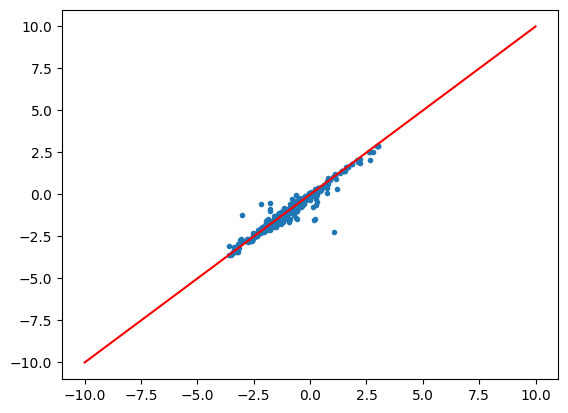

In [36]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [47]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [48]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [49]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_18465/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_18465/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_18465/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [50]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [51]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [52]:
len(closest)

739

In [53]:
y_test_df['Closest'] = closest

In [54]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

682

In [55]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9228687415426252

#### Now let's check if it works for the neural network's output.

In [56]:
model.eval()
outputs = model(X_test)

In [57]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [58]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [59]:
len(closest)

739

In [60]:
outputs_df['Closest'] = closest

In [61]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

599

In [62]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.8105548037889039

In [63]:
outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.8105548037889039

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from seaborn import heatmap

ModuleNotFoundError: No module named 'seaborn'

In [65]:
acc = np.round(100*outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest), 1)
print('Accuracy: '+str(acc)+'%.')

Accuracy: 81.1%.


In [66]:
normalization_in_conf_mat = None

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

tp_and_fn = conf_mat.sum(1)
tp_and_fp = conf_mat.sum(0)
tp = conf_mat.diagonal()

precision = tp / tp_and_fp
recall = tp / tp_and_fn

print('Precision: ' + str(np.nanmean(precision)))
print('Recall: ' + str(np.nanmean(recall)))

Precision: 0.8224691021446747
Recall: 0.8106282817309434


/tmp/ipykernel_18465/2917754103.py:10: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/tmp/ipykernel_18465/2917754103.py:11: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


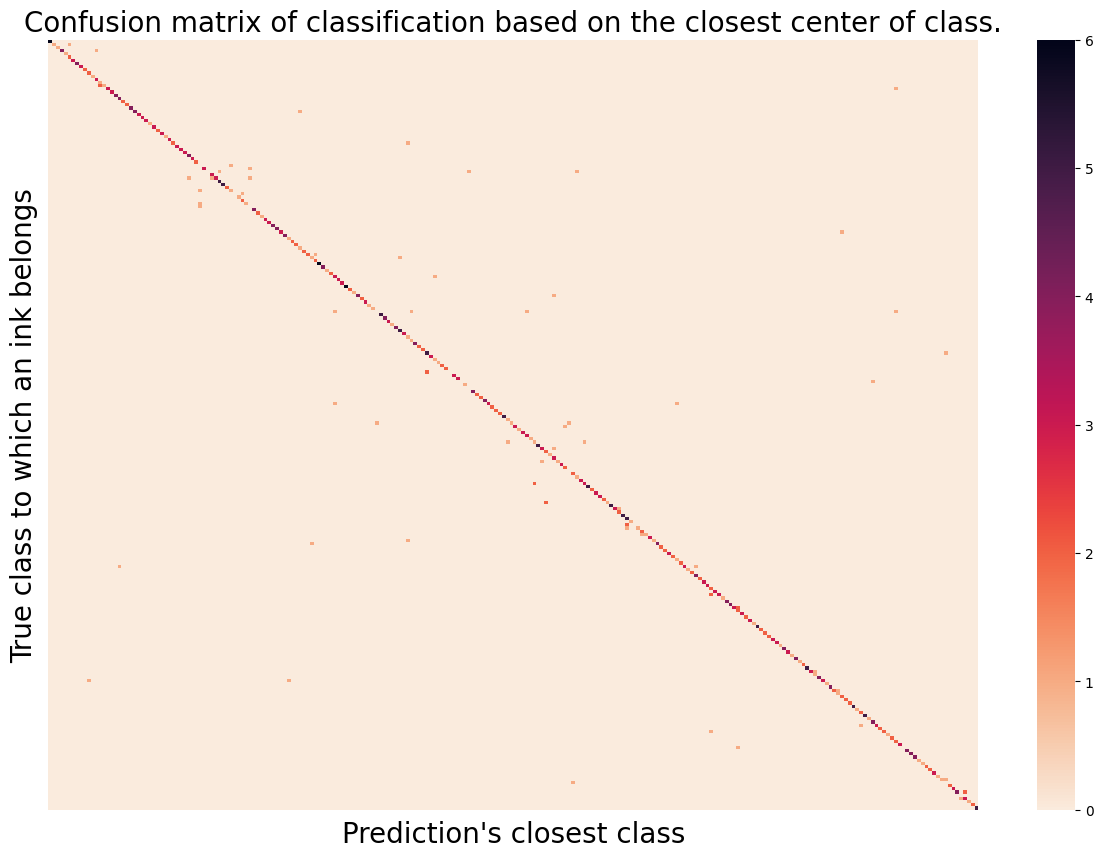

In [75]:
normalization_in_conf_mat = None
scores = {
            'pred': 'Precision',
            'true': 'Recall',
            None: 'Confusion matrix'
            }

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

heatmap(conf_mat, cmap=sns.cm.rocket_r, xticklabels=False, yticklabels=False)
plt.ylabel('True class to which an ink belongs', size=20)
plt.xlabel("Prediction's closest class", size=20)
plt.rcParams['figure.figsize'] = [15, 10]
plt.title(scores[normalization_in_conf_mat] + ' of classification based on the closest center of class.', 
          size=20, 
          wrap=True)

#plt.tight_layout()
plt.savefig('../figures/heatmap_' + scores[normalization_in_conf_mat] + '.png')

## Quality of prediction: confidence intervals

In [67]:
model.eval()
outputs = model(X_test)

In [68]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [69]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [70]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_18465/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_18465/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_18465/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [71]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_18465/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_18465/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_18465/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [72]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [73]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [74]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [75]:
np.array(sd_res_list).mean()

np.float64(0.7944857916102842)

On consecutive coordinates:

In [76]:
np.array(sd_res_list).mean(0)

array([[0.86197564, 0.82814614, 0.92151556, 0.73477673, 0.78213802,
        0.70094723, 0.76860622, 0.75778078]])

Percentage of points inside min-max interval:

In [77]:
np.array(min_max_res_list).mean()

np.float64(0.7023004059539919)

On consecutive coordinates:

In [78]:
np.array(min_max_res_list).mean(0)

array([[0.78755074, 0.74424899, 0.87956698, 0.64140731, 0.65223275,
        0.58322057, 0.68470907, 0.64546685]])

### Visualisations of mean +- 2 * standard deviation intervals

In [ ]:
# fig, ax = plt.subplots(2,4, figsize=(15,8))
# plt.suptitle('Mean +- two standard deviations in classes')
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
#                   xmax=upper_bound_df.iloc[sample_id, element], 
#                   color="blue", linewidth=1)
#         ax[element//4][element%4].set_title(elements_names[element], size=15)
#         if element == 5:
#             ax[element//4][element%4].set_xlim([-0.2, 2.0])
#         if element == 0 or element == 4:
#             ax[element//4][element%4].set_ylabel('Class number')
    
#plt.savefig(figures_path + 'intervals.png', dpi=300)

In [ ]:
element = 0
percentage_correct = np.round(100*(np.array(sd_res_list).mean(0))[0,element], 1)

sorted_upper_bound_df = upper_bound_df.sort_values(upper_bound_df.columns[element])
sorted_upper_bound_df.reset_index(drop=True, inplace=True)
sorted_lower_bound_df = lower_bound_df.iloc[upper_bound_df.sort_values(upper_bound_df.columns[element]).index,:]
sorted_lower_bound_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_lower_bound_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_lower_bound_df.iloc[sample_id, element], 
                  ymax=sorted_upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
    
for row in range(outputs_df.shape[0]):
    new_index = sorted_upper_bound_df[sorted_upper_bound_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xlabel('Number of group',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside +-2 sd confidence interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
#plt.savefig('../figures/confidence_intervals_'+str(outputs_df.columns[element+1]))

### Visualisations of min-max intervals

In [ ]:
# fig, ax = plt.subplots(2,4, figsize=(10,5))
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
#                   ymax=min_max_df.iloc[sample_id, element+1], 
#                   color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

In [ ]:
element = 0
percentage_correct = np.round(100*(np.array(min_max_res_list).mean(0))[0,element], 1)

sorted_min_max_df = min_max_df.sort_values(min_max_df.columns[element+1])
sorted_min_max_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_min_max_df.iloc[sample_id, element+9], 
                  ymax=sorted_min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

for row in range(outputs_df.shape[0]):
    new_index = sorted_min_max_df[sorted_min_max_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xticks([], [])
plt.xlabel('Groups',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside min-max interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
plt.tight_layout()

#plt.savefig('../figures/min_max_intervals_'+str(outputs_df.columns[element+1]))

## Interpretability